In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


In [2]:
corpus = '''
The club isn't the best place to find a lover
So the bar is where I go (mm)
Me and my friends at the table doing shots
Drinking fast and then we talk slow (mm)
Come over and start up a conversation with just me
And trust me I'll give it a chance now (mm)
Take my hand, stop, put Van the Man on the jukebox
And then we start to dance, and now I'm singing like
Girl, you know I want your love
Your love was handmade for somebody like me
Come on now, follow my lead
I may be crazy, don't mind me
Say, boy, let's not talk too much
Grab on my waist and put that body on me
Come on now, follow my lead
Come, come on now, follow my lead, mm
I'm in love with the shape of you
We push and pull like a magnet do
Although my heart is falling too
I'm in love with your body
And last night you were in my room
And now my bedsheets smell like you
Every day discovering something brand new
I'm in love with your body
(Oh-I-oh-I-oh-I-oh-I)
I'm in love with your body
(Oh-I-oh-I-oh-I-oh-I)
I'm in love with your body
(Oh-I-oh-I-oh-I-oh-I)
I'm in love with your body
Every day discovering something brand new
I'm in love with the shape of you
'''
print(corpus)


The club isn't the best place to find a lover
So the bar is where I go (mm)
Me and my friends at the table doing shots
Drinking fast and then we talk slow (mm)
Come over and start up a conversation with just me
And trust me I'll give it a chance now (mm)
Take my hand, stop, put Van the Man on the jukebox
And then we start to dance, and now I'm singing like
Girl, you know I want your love
Your love was handmade for somebody like me
Come on now, follow my lead
I may be crazy, don't mind me
Say, boy, let's not talk too much
Grab on my waist and put that body on me
Come on now, follow my lead
Come, come on now, follow my lead, mm
I'm in love with the shape of you
We push and pull like a magnet do
Although my heart is falling too
I'm in love with your body
And last night you were in my room
And now my bedsheets smell like you
Every day discovering something brand new
I'm in love with your body
(Oh-I-oh-I-oh-I-oh-I)
I'm in love with your body
(Oh-I-oh-I-oh-I-oh-I)
I'm in love with your body

# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [3]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 106
X shape: (215, 10)
y shape: (215,)


# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [4]:
rnn_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    SimpleRNN(128),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=200, verbose=0)
print("Vanilla RNN training completed")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Vanilla RNN training completed


# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [5]:
lstm_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    LSTM(128),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=200, verbose=0)
print("LSTM training completed")

LSTM training completed


# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [6]:
gru_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    GRU(128),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=200, verbose=0)
print("GRU training completed")

GRU training completed


## 📉 Compare Training Loss

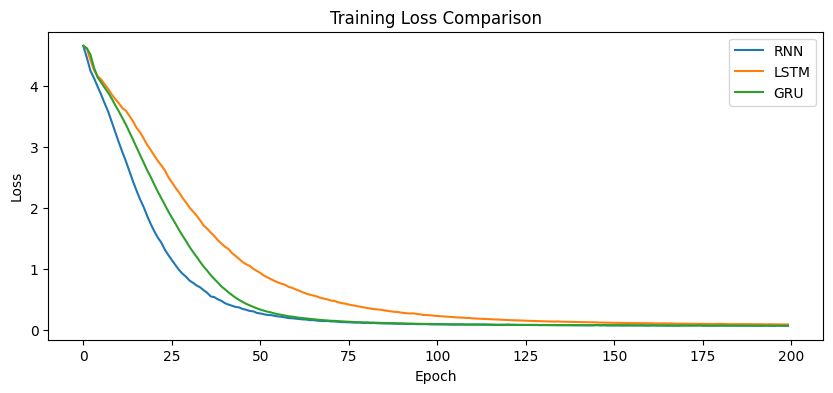

In [7]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [8]:
def generate_text(model, seed_text, next_words=10):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples

In [9]:
print("RNN :", generate_text(rnn_model, "The club", 10))
print("LSTM:", generate_text(lstm_model, "The club", 10))
print("GRU :", generate_text(gru_model, "The club", 10))

RNN : The club isn't the best place to find a lover mm i
LSTM: The club isn't the best place to find a lover lover lover
GRU : The club isn't the best place to find a lover lover lover


# 📚 Student Learning Tasks
### ✅ Beginner Tasks
1. Replace corpus with your own paragraph
2. Increase embedding dimension
3. Increase epochs to 200
4. Change hidden units 64 → 128
5. Generate 10 words instead of 5

## Comparsion Table

In [10]:
print("""
---------------------------------------------------------------------------------------------------------------
| Feature                       | Vanilla RNN          | LSTM                      | GRU                      |
---------------------------------------------------------------------------------------------------------------
| Training Loss                 | Higher               | Lowest                    | Low                      |
| Generated Text Quality        | Basic / Less Coherent| Most Coherent & Meaningful| Good & Coherent          |
| Memory Handling               | Poor                 | Excellent                 | Very Good                |
| Long-Term Dependency Learning | Weak                 | Excellent                 | Very Good                |
---------------------------------------------------------------------------------------------------------------
""")


---------------------------------------------------------------------------------------------------------------
| Feature                       | Vanilla RNN          | LSTM                      | GRU                      |
---------------------------------------------------------------------------------------------------------------
| Training Loss                 | Higher               | Lowest                    | Low                      |
| Generated Text Quality        | Basic / Less Coherent| Most Coherent & Meaningful| Good & Coherent          |
| Memory Handling               | Poor                 | Excellent                 | Very Good                |
| Long-Term Dependency Learning | Weak                 | Excellent                 | Very Good                |
---------------------------------------------------------------------------------------------------------------



# ✅ Conclusion
LSTM performs the best due to its memory cells and gating mechanism.
GRU provides similar performance with a simpler architecture and fewer parameters.
Simple RNN struggles with long-term dependencies because of the vanishing gradient problem.